# Chronos_Bolt_Tiny

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from chronos import BaseChronosPipeline
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

/Users/federicosabbadini/Library/Mobile Documents/com~apple~CloudDocs/Workspaces/gitHub-workspace/patchAliasing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from chronos import BaseChronosPipeline, Chronos2Pipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-tiny",
    device_map="cpu",

)

In [3]:
print(dir(pipeline))

['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_prepare_and_validate_context', 'default_context_length', 'dtypes', 'embed', 'forecast_type', 'from_pretrained', 'inner_model', 'model', 'model_context_length', 'model_prediction_length', 'predict', 'predict_df', 'predict_fev', 'predict_quantiles', 'quantiles']


In [4]:
import torch
import pprint

def inspect_chronos_pipeline(pipeline):
    print("\n================ PIPELINE TYPE ================\n")
    print(type(pipeline))

    print("\n================ TOP-LEVEL ATTRIBUTES ================\n")
    attrs = [a for a in dir(pipeline) if not a.startswith("_")]
    print(attrs)

    print("\n================ KEY ATTRIBUTES (IF PRESENT) ================\n")
    keys = [
        "model_prediction_length",
        "model_context_length",
        "forecast_type",
        "inner_model",
        "model",
        "quantiles",
    ]

    for k in keys:
        if hasattr(pipeline, k):
            print(f"{k}: {getattr(pipeline, k)}")
        else:
            print(f"{k}: NOT FOUND")

    print("\n================ INNER MODEL INFO ================\n")
    if hasattr(pipeline, "inner_model"):
        im = pipeline.inner_model
        print("inner_model type:", type(im))

        # try config
        if hasattr(im, "config"):
            print("\ninner_model.config:")
            pprint.pprint(im.config)

        # try attributes of inner model
        print("\ninner_model attributes:")
        print([a for a in dir(im) if not a.startswith("_")][:50])
    else:
        print("No inner_model")

    print("\n================ PREDICT METHOD SIGNATURE ================\n")
    try:
        import inspect
        print(inspect.signature(pipeline.predict))
    except Exception as e:
        print("Could not inspect predict:", e)

    print("\n================ DEVICE INFO ================\n")
    try:
        p = next(pipeline.inner_model.parameters())
        print("device:", p.device)
        print("dtype:", p.dtype)
    except Exception:
        print("No torch parameters found")

    print("\n================ QUICK SANITY CHECK ================\n")
    try:
        print("model_prediction_length:", getattr(pipeline, "model_prediction_length", None))
        print("context_length:", getattr(pipeline, "model_context_length", None))
    except Exception as e:
        print("error:", e)

inspect_chronos_pipeline(pipeline)


================ PIPELINE TYPE ================

<class 'chronos.chronos_bolt.ChronosBoltPipeline'>

================ TOP-LEVEL ATTRIBUTES ================

['default_context_length', 'dtypes', 'embed', 'forecast_type', 'from_pretrained', 'inner_model', 'model', 'model_context_length', 'model_prediction_length', 'predict', 'predict_df', 'predict_fev', 'predict_quantiles', 'quantiles']

================ KEY ATTRIBUTES (IF PRESENT) ================

model_prediction_length: 64
model_context_length: 2048
forecast_type: ForecastType.QUANTILES
inner_model: ChronosBoltModelForForecasting(
  (shared): Embedding(2, 256)
  (input_patch_embedding): ResidualBlock(
    (dropout): Dropout(p=0.1, inplace=False)
    (hidden_layer): Linear(in_features=32, out_features=1024, bias=True)
    (act): ReLU()
    (output_layer): Linear(in_features=1024, out_features=256, bias=True)
    (residual_layer): Linear(in_features=32, out_features=256, bias=True)
  )
  (patch): Patch()
  (instance_norm): InstanceNor

## Model

In [5]:
model = pipeline.model

print(type(model))

<class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>


In [6]:
print(pipeline.model.config)

T5Config {
  "architectures": [
    "ChronosBoltModelForForecasting"
  ],
  "chronos_config": {
    "context_length": 2048,
    "input_patch_size": 16,
    "input_patch_stride": 16,
    "prediction_length": 64,
    "quantiles": [
      0.1,
      0.2,
      0.3,
      0.4,
      0.5,
      0.6,
      0.7,
      0.8,
      0.9
    ],
    "use_reg_token": true
  },
  "chronos_pipeline_class": "ChronosBoltPipeline",
  "classifier_dropout": 0.0,
  "d_ff": 1024,
  "d_kv": 64,
  "d_model": 256,
  "decoder_start_token_id": 0,
  "dense_act_fn": "relu",
  "dropout_rate": 0.1,
  "dtype": "float32",
  "eos_token_id": 1,
  "feed_forward_proj": "relu",
  "initializer_factor": 0.05,
  "is_encoder_decoder": true,
  "is_gated_act": false,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 4,
  "num_heads": 4,
  "num_layers": 4,
  "pad_token_id": 0,
  "reg_token_id": 1,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "t

### Layers

In [7]:
pre_transformer_modules = []
encoder_modules = []
decoder_modules = []
post_transformer_modules = []

modules = []
for name, module in model.named_modules():
    modules.append((name, module))


In [8]:
for name, module in modules:
    if "encoder" not in name:
        pre_transformer_modules.append((name, module))
        modules.remove((name, module))
    else:
        break

i = 0
for name, module in pre_transformer_modules:
    if i == 0:
        print(f"Pre-transformer modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Pre-transformer modules: <class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>
1: input_patch_embedding: <class 'chronos.chronos_bolt.ResidualBlock'>
2: input_patch_embedding.hidden_layer: <class 'torch.nn.modules.linear.Linear'>
3: input_patch_embedding.output_layer: <class 'torch.nn.modules.linear.Linear'>
4: patch: <class 'chronos.chronos_bolt.Patch'>


In [9]:
for name, module in modules:
    if "encoder" in name and "decoder" not in name:
        encoder_modules.append((name, module))
        modules.remove((name, module))
        
i = 0
for name, module in encoder_modules:
    if i == 0:
        print(f"Encoder modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Encoder modules: <class 'transformers.models.t5.modeling_t5.T5Stack'>
1: encoder.block.0: <class 'transformers.models.t5.modeling_t5.T5Block'>
2: encoder.block.0.layer.0: <class 'transformers.models.t5.modeling_t5.T5LayerSelfAttention'>
3: encoder.block.0.layer.0.SelfAttention.q: <class 'torch.nn.modules.linear.Linear'>
4: encoder.block.0.layer.0.SelfAttention.v: <class 'torch.nn.modules.linear.Linear'>
5: encoder.block.0.layer.0.SelfAttention.relative_attention_bias: <class 'torch.nn.modules.sparse.Embedding'>
6: encoder.block.0.layer.0.dropout: <class 'torch.nn.modules.dropout.Dropout'>
7: encoder.block.0.layer.1.DenseReluDense: <class 'transformers.models.t5.modeling_t5.T5DenseActDense'>
8: encoder.block.0.layer.1.DenseReluDense.wo: <class 'torch.nn.modules.linear.Linear'>
9: encoder.block.0.layer.1.DenseReluDense.act: <class 'torch.nn.modules.activation.ReLU'>
10: encoder.block.0.layer.1.dropout: <class 'torch.nn.modules.dropout.Dropout'>
11: encoder.block.1.layer: <class 'torch.nn

In [10]:
for name, module in modules:
    if "decoder" in name:
        decoder_modules.append((name, module))
        modules.remove((name, module))

i = 0
for name, module in decoder_modules:
    if i == 0:
        print(f"Decoder modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Decoder modules: <class 'transformers.models.t5.modeling_t5.T5Stack'>
1: decoder.block.0: <class 'transformers.models.t5.modeling_t5.T5Block'>
2: decoder.block.0.layer.0: <class 'transformers.models.t5.modeling_t5.T5LayerSelfAttention'>
3: decoder.block.0.layer.0.SelfAttention.q: <class 'torch.nn.modules.linear.Linear'>
4: decoder.block.0.layer.0.SelfAttention.v: <class 'torch.nn.modules.linear.Linear'>
5: decoder.block.0.layer.0.SelfAttention.relative_attention_bias: <class 'torch.nn.modules.sparse.Embedding'>
6: decoder.block.0.layer.0.dropout: <class 'torch.nn.modules.dropout.Dropout'>
7: decoder.block.0.layer.1.EncDecAttention: <class 'transformers.models.t5.modeling_t5.T5Attention'>
8: decoder.block.0.layer.1.EncDecAttention.k: <class 'torch.nn.modules.linear.Linear'>
9: decoder.block.0.layer.1.EncDecAttention.o: <class 'torch.nn.modules.linear.Linear'>
10: decoder.block.0.layer.1.dropout: <class 'torch.nn.modules.dropout.Dropout'>
11: decoder.block.0.layer.2.DenseReluDense: <clas

In [11]:
for name, module in modules[20:]:
    if "encoder" not in name and "decoder" not in name:
        post_transformer_modules.append((name, module))

i = 0
for name, module in post_transformer_modules:
    if i == 0:
        print(f"Post-transformer modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Post-transformer modules: <class 'chronos.chronos_bolt.ResidualBlock'>
1: output_patch_embedding.dropout: <class 'torch.nn.modules.dropout.Dropout'>
2: output_patch_embedding.hidden_layer: <class 'torch.nn.modules.linear.Linear'>
3: output_patch_embedding.act: <class 'torch.nn.modules.activation.ReLU'>
4: output_patch_embedding.output_layer: <class 'torch.nn.modules.linear.Linear'>
5: output_patch_embedding.residual_layer: <class 'torch.nn.modules.linear.Linear'>


## Embeddings Learning

In [12]:
captured = {
    "patches": None, # This will be a list of tensors, one for each patch, containing the raw pixel values of the patch.
    "patch_embeddings": None, # This will be a list of tensors, one for each patch, containing the embeddings of the patches after the patch embedding layer.
    "encoder_inputs": None, # This will be a list of tensors, one for each patch, containing the inputs to the encoder after the positional encoding and patch embedding layers.
}

### Hooks

In [13]:
# Hook is a function that will be called every time the module/layer is called. 
# Using PyTorch forward, hooks to “spy on” intermediate values inside a neural network while it runs.


# Dictionary to store captured tensors
captured = {}
# List to keep hook handles
hooks = []

\
def to_cpu(x):
    """
    Utility function to move tensors to CPU and detach them from the computation graph.
    This is useful for storing intermediate values without keeping the entire computation graph in memory.
    """
    if torch.is_tensor(x):
        # Detach the tensor from the computation graph and move it to CPU
        return x.detach().cpu()
    elif isinstance(x, tuple):
            # If the input is a tuple, apply to_cpu to each element in the tuple and return a new tuple with the results
            return tuple(to_cpu(item) for item in x)
    else:  
        # If the input is neither a tensor nor a tuple, return it as is (e.g., for non-tensor inputs)
        return x

In [14]:
def remove_hooks():
    """
    Utility function to remove all hooks that have been registered.
    This should be called after we are done capturing intermediate values to clean up the hooks and prevent
    memory leaks.
    """
    for h in hooks:
        h.remove()

#### 1. Scaling Hook

Scaling/Norm is the first step in the patch embedding layer. 
- It takes the raw pixel values of the patches and scales them to a range that is more suitable for the model to process. 
- We want to capture the outputs of this step to analyze how the model is processing the input patches.

In [15]:
def norm_hook(module, inputs, outputs):
    """
    Hook function to capture the output of the instance normalization layer.
    The outputs are moved to CPU and detached from the computation graph to save memory.
    """
    captured["normalized"] = to_cpu(outputs)

In [16]:
hooks.append(
    model.instance_norm.register_forward_hook(norm_hook)
)

#### 2. Patch Hook

Patch embedding layer is the second layer of patch embedding, before the embedding NN.
- It fixes the patch size and the number of patches, and it is responsible for extracting the raw pixel values of the patches and reshaping them into a sequence of patch tokens.
- If the input is not long enough, it will pad it with NaN with left padding, so that the last patch is always the one with the padding, and the first patch is always the one with the raw pixel values. This way we can easily identify which patch is which, and we can easily remove the padding if needed.

In [17]:
def patch_hook(module, inputs, outputs):
    captured["patch"] = to_cpu(outputs)

In [18]:
hooks.append(
    model.patch.register_forward_hook(patch_hook)
)

#### 3. Embedding_NN Hook

This layer concern applying a NN to patch+norm inputs, transforming them into patch embeddings to give in input to the transformer.
It is divided in several sub-layers, and we want to capture the output of each of them to understand how the patch embeddings are computed.
- 1. INPUT TO PATCH EMBEDDING = output of the patch embedding module, before the first linear layer.
- 2. HIDDEN LAYER OUTPUT = output of the first linear layer in the patch embedding module, before the activation function.
- 3. RELU ACTIVATIONS = output of the activation function in the patch embedding module.
- 4. OUTPUT LINEAR LAYER = output of the final linear layer in the patch embedding module.
- 5. RESIDUAL PATHWAY = output of the residual connection in the patch embedding module.

##### 3.1 Input_NN Hook

In [19]:
def embedding_input_hook(module, inputs):

    if len(inputs) > 0:
        captured["embedding_input"] = to_cpu(inputs[0])

In [20]:
hooks.append(
    model.input_patch_embedding.hidden_layer.register_forward_pre_hook(
        embedding_input_hook
    )
)

##### 3.2. Hidden_NN Hook

In [21]:
def hidden_hook(module, inputs, outputs):

    captured["hidden"] = to_cpu(outputs)

In [22]:
hooks.append(
    model.input_patch_embedding.hidden_layer.register_forward_hook(
        hidden_hook
    )
)

##### 3.3. Relu_NN Hook

In [23]:
def relu_hook(module, inputs, outputs):

    captured["relu"] = to_cpu(outputs)

In [24]:
hooks.append(
    model.input_patch_embedding.act.register_forward_hook(
        relu_hook
    )
)

##### 3.4. Output_NN Hook

In [25]:
def output_hook(module, inputs, outputs):

    captured["output_linear"] = to_cpu(outputs)

In [26]:
hooks.append(
    model.input_patch_embedding.output_layer.register_forward_hook(
        output_hook
    )
)

##### 3.5. Resiual_NN Hook

In [27]:
def residual_hook(module, inputs, outputs):

    captured["residual"] = to_cpu(outputs)

In [28]:
hooks.append(
    model.input_patch_embedding.residual_layer.register_forward_hook(
        residual_hook
    )
)

#### 4. Final Embeddings Hook

Finally, we want to capture the final patch embeddings that are fed into the transformer encoder layers.

In [29]:
def final_embedding_hook(module, inputs, outputs):

    captured["final_embedding"] = to_cpu(outputs)

In [30]:
hooks.append(
    model.input_patch_embedding.register_forward_hook(
        final_embedding_hook
    )
)

### Input

In [31]:
series1 = torch.tensor([
    11.0, 1.2, 1.4, 1.1,
    0.9, 1.3, 1.5, 1.7,
    1.8, 1.6, 1.4, 1.2,
    1.1, 1.0, 0.8, 0.7,
    0.9, 1.1, 1.3, 1.5,
    1.7, 1.9, 2.0, 1.8,
    1.6, 1.4, 1.2, 1.0,
], dtype=torch.float32)

In [32]:
series2 = torch.tensor([
    0.5, 0.6, 0.7, 0.8,
    0.9, 1.0, 1.1, 1.2,
    1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3,
    2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1,
], dtype=torch.float32)

In [33]:
series3 = torch.tensor([
    2.0, 1.9, 1.8, 1.7,
    1.6, 1.5, 1.4, 1.3,
    1.2, 1.1, 1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2,  
    0.1, 0.0, -0.1, -0.2, -0.3, -0.4,
], dtype=torch.float32)

In [34]:
input = series1 

print("Input series shape:", input.shape)
# We are UNIVARIATE, so we have only one feature dimension. If the model expects a feature dimension, we need to add it.
# input = input.unsqueeze(-1)  # Add a feature dimension to the input series
# print("Input series shape after adding feature dimension:", input.shape)
input = input.unsqueeze(0)  # Add batch dimension
print("Input series shape after adding batch dimension:", input.shape)

Input series shape: torch.Size([28])
Input series shape after adding batch dimension: torch.Size([1, 28])


### Processing

In [35]:
with torch.no_grad():

    with torch.no_grad():
        forecast = pipeline.predict(
            input,
            prediction_length=11,
        )

In [36]:
remove_hooks()

patch = captured["patch"]
normalized = captured["normalized"]
embedding_input = captured["embedding_input"]
hidden = captured["hidden"]
relu = captured["relu"]
output_linear = captured["output_linear"]
residual = captured["residual"]
final_embedding = captured["final_embedding"]

remember = {}
def print_remember():
    for key, value in remember.items():
        if value is not None and key is not None:
            print(f"REMEMBER -- {key}: {value}")

In [37]:
print("\n================================================")
print("0. INPUT SERIES")
print("================================================")

input_shape = input.shape
print("Shape:", input_shape)

for i in range(input_shape[1]):
    print(f"Value {i}: {input[0, i].item()}")
    
remember["Input shape"] = input_shape


0. INPUT SERIES
Shape: torch.Size([1, 28])
Value 0: 11.0
Value 1: 1.2000000476837158
Value 2: 1.399999976158142
Value 3: 1.100000023841858
Value 4: 0.8999999761581421
Value 5: 1.2999999523162842
Value 6: 1.5
Value 7: 1.7000000476837158
Value 8: 1.7999999523162842
Value 9: 1.600000023841858
Value 10: 1.399999976158142
Value 11: 1.2000000476837158
Value 12: 1.100000023841858
Value 13: 1.0
Value 14: 0.800000011920929
Value 15: 0.699999988079071
Value 16: 0.8999999761581421
Value 17: 1.100000023841858
Value 18: 1.2999999523162842
Value 19: 1.5
Value 20: 1.7000000476837158
Value 21: 1.899999976158142
Value 22: 2.0
Value 23: 1.7999999523162842
Value 24: 1.600000023841858
Value 25: 1.399999976158142
Value 26: 1.2000000476837158
Value 27: 1.0


In [38]:
print_remember()
print("\n================================================")
print("1. PATCH MODULE OUTPUT")
print("================================================")

patch_shape = patch.shape
print("Shape:", patch_shape)

for i in range(patch_shape[1]):
    print(f"\nPatch {i}:")
    print(patch[0, i])

remember["Patch shape"] = patch_shape

REMEMBER -- Input shape: torch.Size([1, 28])

1. PATCH MODULE OUTPUT
Shape: torch.Size([1, 2, 16])

Patch 0:
tensor([nan, nan, nan, nan, 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 1:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


In [39]:
print_remember()
print("\n================================================")
print("2. NORMALIZED SERIES")
print("================================================")

if isinstance(normalized, tuple):
    normalized_values, normalized_stats = normalized
    normalized = normalized_values  # keep the rest of the cell compatible

norm_shape = normalized.shape
print("Shape:", norm_shape)

for i in range(norm_shape[1]):
    print(f"\nNormalized Value {i}:")
    print(normalized[0, i])

remember["Normalized shape"] = norm_shape

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])

2. NORMALIZED SERIES
Shape: torch.Size([1, 28])

Normalized Value 0:
tensor(5.1067)

Normalized Value 1:
tensor(-0.2642)

Normalized Value 2:
tensor(-0.1546)

Normalized Value 3:
tensor(-0.3190)

Normalized Value 4:
tensor(-0.4287)

Normalized Value 5:
tensor(-0.2094)

Normalized Value 6:
tensor(-0.0998)

Normalized Value 7:
tensor(0.0098)

Normalized Value 8:
tensor(0.0646)

Normalized Value 9:
tensor(-0.0450)

Normalized Value 10:
tensor(-0.1546)

Normalized Value 11:
tensor(-0.2642)

Normalized Value 12:
tensor(-0.3190)

Normalized Value 13:
tensor(-0.3738)

Normalized Value 14:
tensor(-0.4835)

Normalized Value 15:
tensor(-0.5383)

Normalized Value 16:
tensor(-0.4287)

Normalized Value 17:
tensor(-0.3190)

Normalized Value 18:
tensor(-0.2094)

Normalized Value 19:
tensor(-0.0998)

Normalized Value 20:
tensor(0.0098)

Normalized Value 21:
tensor(0.1194)

Normalized Value 22:
tensor(0.1742)


In [40]:
print_remember()
print("\n================================================")
print("3. EMBEDDING INPUT")
print("================================================")

embedding_input_shape = embedding_input.shape
print("Shape:", embedding_input_shape)

for i in range(embedding_input_shape[1]):
    print(f"\nEmbedding Input {i}:")
    print(embedding_input[0, i])

remember["Embedding Input shape"] = embedding_input_shape

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])
REMEMBER -- Normalized shape: torch.Size([1, 28])

3. EMBEDDING INPUT
Shape: torch.Size([1, 2, 32])

Embedding Input 0:
tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  5.1067, -0.2642, -0.1546, -0.3190,
        -0.4287, -0.2094, -0.0998,  0.0098,  0.0646, -0.0450, -0.1546, -0.2642,
         0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000])

Embedding Input 1:
tensor([-0.3190, -0.3738, -0.4835, -0.5383, -0.4287, -0.3190, -0.2094, -0.0998,
         0.0098,  0.1194,  0.1742,  0.0646, -0.0450, -0.1546, -0.2642, -0.3738,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000])


In [41]:
print_remember()
print("\n================================================")
print("4. HIDDEN FEATURES")
print("================================================")

hidden_shape = hidden.shape
print("Shape:", hidden_shape)

for i in range(hidden_shape[1]):
    print(f"\nHidden Feature {i}:")
    print(hidden[0, i])

remember["Hidden shape"] = hidden_shape

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])
REMEMBER -- Normalized shape: torch.Size([1, 28])
REMEMBER -- Embedding Input shape: torch.Size([1, 2, 32])

4. HIDDEN FEATURES
Shape: torch.Size([1, 2, 1024])

Hidden Feature 0:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.7809, -0.4014])

Hidden Feature 1:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.7939, -0.4014])


In [42]:
print_remember()
print("\n================================================")
print("5. RELU ACTIVATIONS")
print("================================================")

relu_shape = relu.shape
print("Shape:", relu_shape)

for i in range(relu_shape[1]):
    print(f"\nReLU Activation {i}:")
    print(relu[0, i])

remember["ReLU shape"] = relu_shape

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])
REMEMBER -- Normalized shape: torch.Size([1, 28])
REMEMBER -- Embedding Input shape: torch.Size([1, 2, 32])
REMEMBER -- Hidden shape: torch.Size([1, 2, 1024])

5. RELU ACTIVATIONS
Shape: torch.Size([1, 2, 1024])

ReLU Activation 0:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 1:
tensor([0., 0., 0.,  ..., 0., 0., 0.])


In [43]:
print_remember()
print("\n================================================")
print("6. OUTPUT LINEAR")
print("================================================")

output_linear_shape = output_linear.shape
print("Shape:", output_linear.shape)
    
for i in range(output_linear.shape[1]):
    print(f"\nOutput Linear {i}:")
    print(output_linear[0, i])

remember["Output Linear shape"] = output_linear_shape

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])
REMEMBER -- Normalized shape: torch.Size([1, 28])
REMEMBER -- Embedding Input shape: torch.Size([1, 2, 32])
REMEMBER -- Hidden shape: torch.Size([1, 2, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 2, 1024])

6. OUTPUT LINEAR
Shape: torch.Size([1, 2, 256])

Output Linear 0:
tensor([ 4.1953e-02,  3.3861e-02, -8.1634e-03,  2.1540e-03,  1.0281e-02,
         6.5306e-02,  3.8163e-04, -2.3287e-02, -2.5630e-02, -6.2457e-03,
         1.5583e-02, -1.6793e-02, -2.6991e-02,  2.7638e-03, -8.0685e-02,
         2.9153e-02,  1.7013e-02,  3.1343e-02, -6.1226e-02, -4.6729e-03,
        -8.4008e-03, -2.5924e-02,  3.4065e-02,  5.2430e-02,  3.7350e-02,
         1.2399e-01, -3.2798e-02, -3.5385e-02,  2.1685e-02, -8.0012e-03,
         1.4388e-02, -3.4353e-02,  7.1716e-02,  1.2933e-02, -4.4944e-02,
         2.3176e-02,  4.3427e-05, -2.3685e-02,  8.8451e-02,  3.1047e-02,
        -7.4865e-03, -3.9239e-02,  2.3732e-02,  

In [44]:
print_remember()
print("\n================================================")
print("7. RESIDUAL PATHWAY")
print("================================================")

residual_shape = residual.shape
print("Shape:", residual.shape)

for i in range(residual.shape[1]):
    print(f"\nResidual {i}:")
    print(residual[0, i])

remember["Residual shape"] = residual_shape

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])
REMEMBER -- Normalized shape: torch.Size([1, 28])
REMEMBER -- Embedding Input shape: torch.Size([1, 2, 32])
REMEMBER -- Hidden shape: torch.Size([1, 2, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 2, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 2, 256])

7. RESIDUAL PATHWAY
Shape: torch.Size([1, 2, 256])

Residual 0:
tensor([ 8.4169e-02, -3.6192e-02,  9.8952e-02,  8.6696e-02, -2.2222e-02,
        -3.3394e-02, -6.4723e-02, -7.1259e-02,  6.8668e-02,  1.1212e-02,
        -3.8756e-03, -1.2765e-01,  3.7535e-01,  2.0802e-02,  2.4717e-02,
        -1.5089e-01, -6.3491e-02, -1.7748e-02,  2.5980e-02,  6.1639e-02,
        -1.7413e-01,  1.7823e-02, -8.2555e-02, -5.8503e-02,  1.7687e-02,
        -1.5691e-01,  4.4799e-02,  2.3614e-02, -1.6752e-01, -4.7067e-02,
         1.0039e-01, -3.5746e-02, -1.0156e-01, -2.3441e-02, -4.2288e-02,
         1.8796e-02, -3.2889e-03,  1.3493e-02, -5.3956e-02,  2.402

In [45]:
print_remember()
print("\n================================================")
print("8. FINAL PATCH EMBEDDINGS")
print("================================================")

final_embedding_shape = final_embedding.shape
print("Shape:", final_embedding_shape)

batch, num_patches, d_model = final_embedding_shape
for i in range(num_patches):
    print(f"\nFinal Embedding {i}:")
    print(final_embedding[0, i])

remember["Final Embedding shape"] = final_embedding_shape

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])
REMEMBER -- Normalized shape: torch.Size([1, 28])
REMEMBER -- Embedding Input shape: torch.Size([1, 2, 32])
REMEMBER -- Hidden shape: torch.Size([1, 2, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 2, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 2, 256])
REMEMBER -- Residual shape: torch.Size([1, 2, 256])

8. FINAL PATCH EMBEDDINGS
Shape: torch.Size([1, 2, 256])

Final Embedding 0:
tensor([ 1.2612e-01, -2.3305e-03,  9.0789e-02,  8.8850e-02, -1.1941e-02,
         3.1912e-02, -6.4341e-02, -9.4546e-02,  4.3038e-02,  4.9662e-03,
         1.1707e-02, -1.4445e-01,  3.4836e-01,  2.3566e-02, -5.5968e-02,
        -1.2173e-01, -4.6478e-02,  1.3595e-02, -3.5245e-02,  5.6966e-02,
        -1.8253e-01, -8.1013e-03, -4.8491e-02, -6.0737e-03,  5.5036e-02,
        -3.2916e-02,  1.2001e-02, -1.1771e-02, -1.4584e-01, -5.5068e-02,
         1.1478e-01, -7.0098e-02, -2.9848e-02, -1.0509e-02, -8.7233e-02,
 

In [46]:
print_remember()
print("\n================================================")
print("FORECAST")
print("================================================")

forecast_shape = forecast.shape
print("Shape:", forecast_shape)
# the forecast shape is (batch_size, prediction_length, num_features), 
# where num_features is 1 for univariate forecasting. 
# So we can print the forecast as a list of values for each time step in the forecast horizon.

print("\nForecast:" )
print(forecast)

REMEMBER -- Input shape: torch.Size([1, 28])
REMEMBER -- Patch shape: torch.Size([1, 2, 16])
REMEMBER -- Normalized shape: torch.Size([1, 28])
REMEMBER -- Embedding Input shape: torch.Size([1, 2, 32])
REMEMBER -- Hidden shape: torch.Size([1, 2, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 2, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 2, 256])
REMEMBER -- Residual shape: torch.Size([1, 2, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 2, 256])

FORECAST
Shape: torch.Size([1, 9, 11])

Forecast:
tensor([[[0.9210, 0.8734, 0.8585, 0.8479, 0.8512, 0.8456, 0.8253, 0.8189,
          0.8184, 0.7846, 0.7937],
         [0.9975, 0.9725, 0.9534, 0.9451, 0.9605, 0.9578, 0.9431, 0.9278,
          0.9226, 0.8866, 0.8929],
         [1.0440, 1.0196, 1.0063, 0.9922, 1.0201, 1.0202, 1.0006, 0.9854,
          0.9802, 0.9379, 0.9362],
         [1.0723, 1.0450, 1.0347, 1.0266, 1.0632, 1.0598, 1.0358, 1.0199,
          1.0157, 0.9643, 0.9574],
         [1.0926, 1.0671, 1.0590, 1.0562, 1.

### Stats

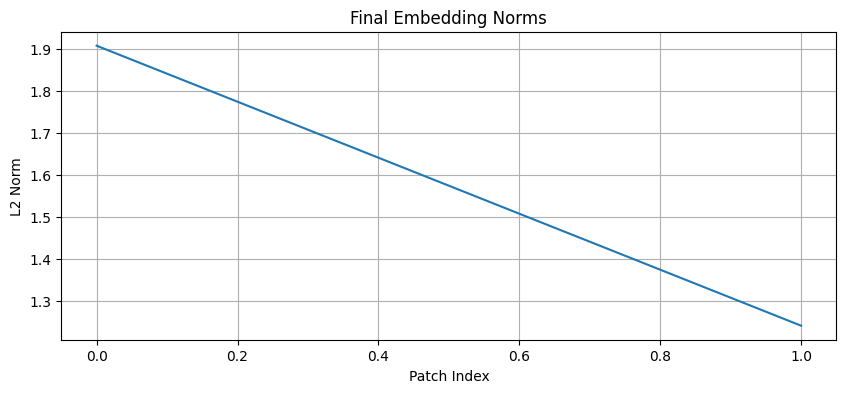

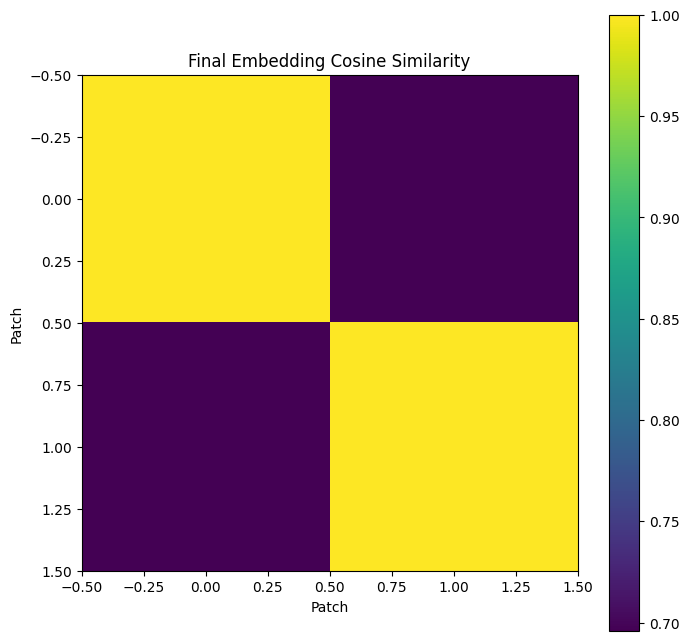

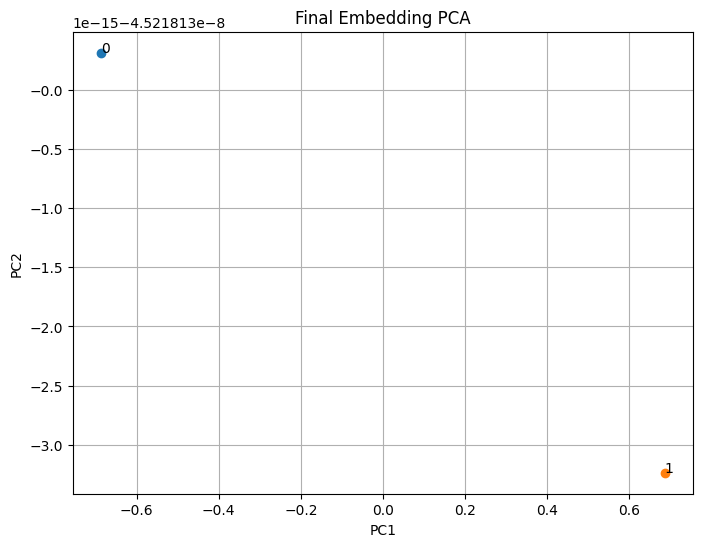

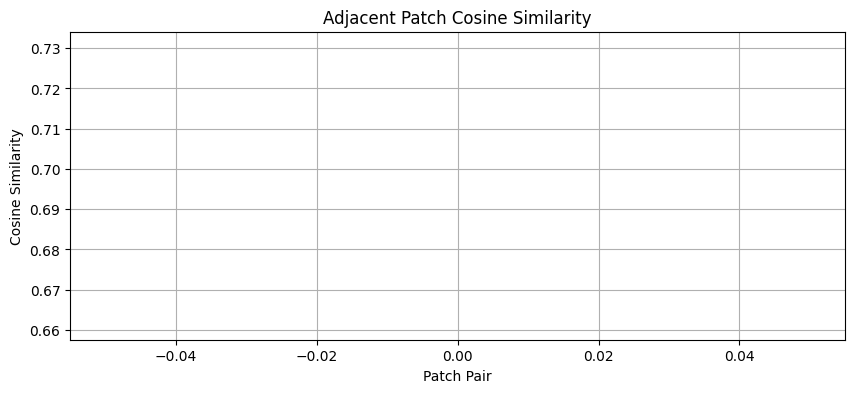

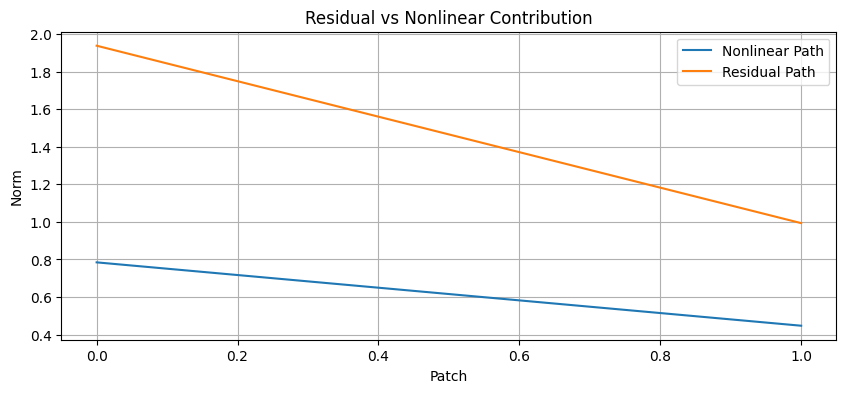


FORECAST
tensor([[[0.9210, 0.8734, 0.8585, 0.8479, 0.8512, 0.8456, 0.8253, 0.8189,
          0.8184, 0.7846, 0.7937],
         [0.9975, 0.9725, 0.9534, 0.9451, 0.9605, 0.9578, 0.9431, 0.9278,
          0.9226, 0.8866, 0.8929],
         [1.0440, 1.0196, 1.0063, 0.9922, 1.0201, 1.0202, 1.0006, 0.9854,
          0.9802, 0.9379, 0.9362],
         [1.0723, 1.0450, 1.0347, 1.0266, 1.0632, 1.0598, 1.0358, 1.0199,
          1.0157, 0.9643, 0.9574],
         [1.0926, 1.0671, 1.0590, 1.0562, 1.1004, 1.0989, 1.0687, 1.0522,
          1.0474, 0.9846, 0.9752],
         [1.1172, 1.0887, 1.0884, 1.0912, 1.1478, 1.1505, 1.1167, 1.0987,
          1.1008, 1.0258, 1.0121],
         [1.1578, 1.1311, 1.1384, 1.1575, 1.2280, 1.2388, 1.2110, 1.1932,
          1.2001, 1.1244, 1.1105],
         [1.2558, 1.2482, 1.2843, 1.3409, 1.4504, 1.4962, 1.4837, 1.4698,
          1.4930, 1.4069, 1.4006],
         [1.7405, 1.8416, 1.9821, 2.1120, 2.3252, 2.4340, 2.4791, 2.5053,
          2.5524, 2.4631, 2.4795]]])


In [47]:

# ============================================================
# EMBEDDING NORMS
# ============================================================

norms = torch.norm(final_embedding[0], dim=-1)

plt.figure(figsize=(10, 4))

plt.plot(norms.numpy())

plt.title("Final Embedding Norms")

plt.xlabel("Patch Index")

plt.ylabel("L2 Norm")

plt.grid()

plt.show()


# ============================================================
# COSINE SIMILARITY
# ============================================================

X = final_embedding[0].numpy()

sim = cosine_similarity(X)

plt.figure(figsize=(8, 8))

plt.imshow(sim)

plt.colorbar()

plt.title("Final Embedding Cosine Similarity")

plt.xlabel("Patch")

plt.ylabel("Patch")

plt.show()


# ============================================================
# PCA
# ============================================================

pca = PCA(n_components=2)

Y = pca.fit_transform(X)

plt.figure(figsize=(8, 6))

for i in range(num_patches):

    plt.scatter(Y[i, 0], Y[i, 1])

    plt.text(Y[i, 0], Y[i, 1], str(i))

plt.title("Final Embedding PCA")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid()

plt.show()


# ============================================================
# TEMPORAL ADJACENT SIMILARITY
# ============================================================

adjacent = []

for i in range(num_patches - 1):

    a = X[i]

    b = X[i + 1]

    cos = np.dot(a, b) / (
        np.linalg.norm(a)
        * np.linalg.norm(b)
    )

    adjacent.append(cos)

plt.figure(figsize=(10, 4))

plt.plot(adjacent)

plt.title("Adjacent Patch Cosine Similarity")

plt.xlabel("Patch Pair")

plt.ylabel("Cosine Similarity")

plt.grid()

plt.show()


# ============================================================
# RESIDUAL VS NONLINEAR CONTRIBUTION
# ============================================================

nonlinear_norm = torch.norm(output_linear[0], dim=-1)

residual_norm = torch.norm(residual[0], dim=-1)

plt.figure(figsize=(10, 4))

plt.plot(
    nonlinear_norm.numpy(),
    label="Nonlinear Path"
)

plt.plot(
    residual_norm.numpy(),
    label="Residual Path"
)

plt.title("Residual vs Nonlinear Contribution")

plt.xlabel("Patch")

plt.ylabel("Norm")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# FORECAST
# ============================================================

print("\n================================================")
print("FORECAST")
print("================================================")

print(forecast)

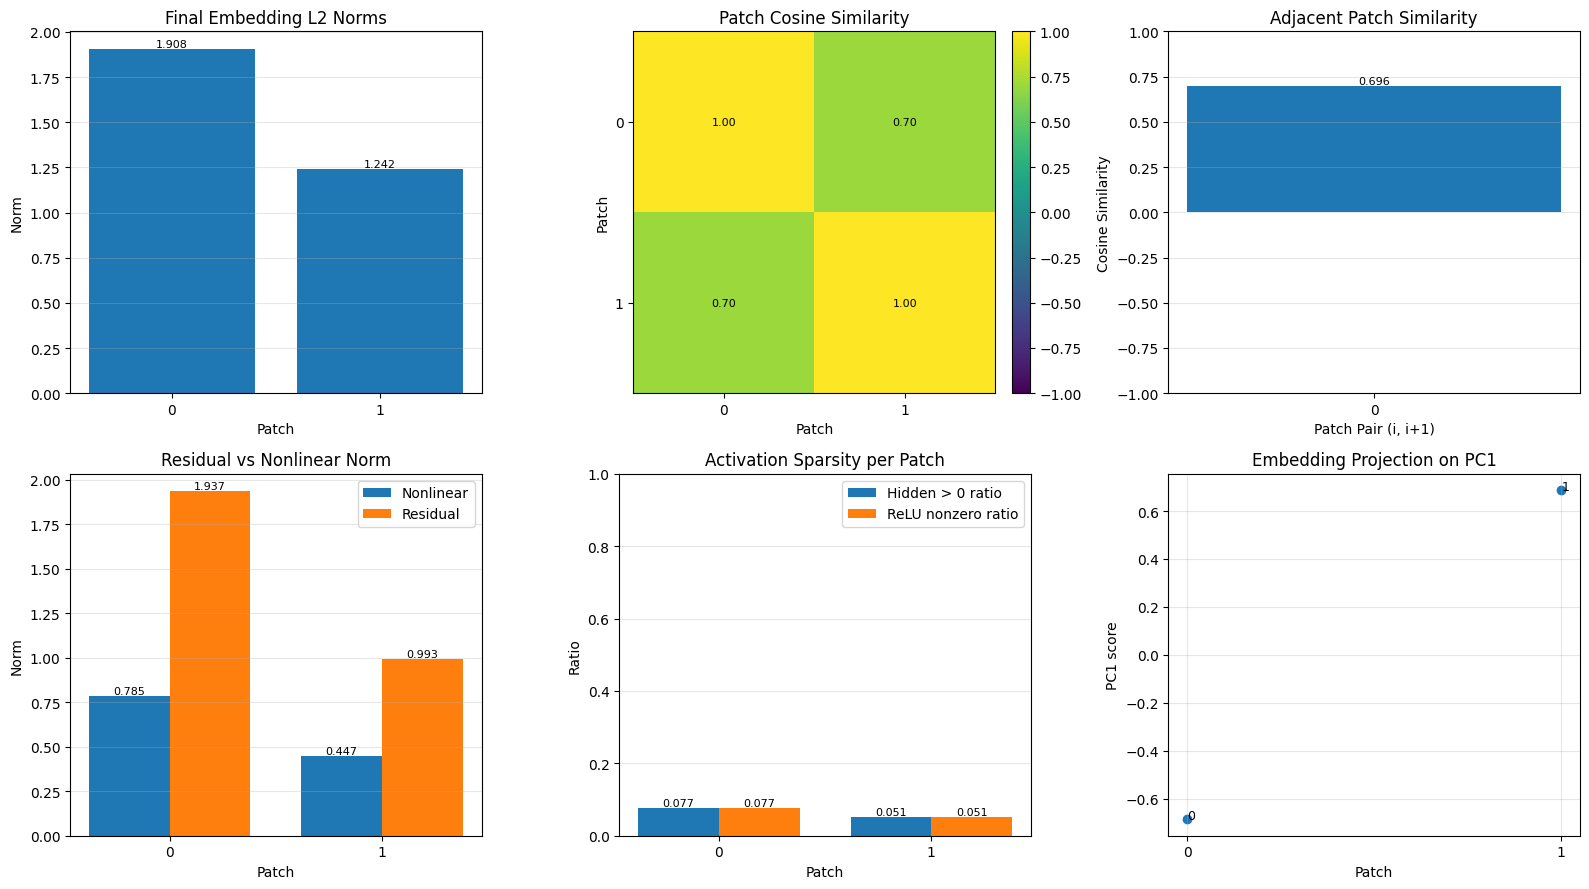

In [48]:
# Improved diagnostics for the current run (works well even with only 2 patches)

X = final_embedding[0].numpy()
n = X.shape[0]

embedding_norms = np.linalg.norm(X, axis=1)
sim_matrix = cosine_similarity(X)

nonlinear_norm_np = torch.norm(output_linear[0], dim=-1).numpy()
residual_norm_np = torch.norm(residual[0], dim=-1).numpy()

hidden_pos_ratio = (hidden[0] > 0).float().mean(dim=-1).numpy()
relu_nonzero_ratio = (relu[0] > 0).float().mean(dim=-1).numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1) Embedding norms
ax = axes[0, 0]
bars = ax.bar(np.arange(n), embedding_norms)
ax.set_title("Final Embedding L2 Norms")
ax.set_xlabel("Patch")
ax.set_ylabel("Norm")
ax.set_xticks(np.arange(n))
ax.grid(axis="y", alpha=0.3)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
            ha="center", va="bottom", fontsize=8)

# 2) Cosine similarity heatmap
ax = axes[0, 1]
im = ax.imshow(sim_matrix, vmin=-1, vmax=1)
ax.set_title("Patch Cosine Similarity")
ax.set_xlabel("Patch")
ax.set_ylabel("Patch")
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
for r in range(n):
    for c in range(n):
        ax.text(c, r, f"{sim_matrix[r, c]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 3) Adjacent similarity (bar is clearer with few patches)
ax = axes[0, 2]
if n > 1:
    adjacent = [sim_matrix[i, i + 1] for i in range(n - 1)]
    bars = ax.bar(np.arange(len(adjacent)), adjacent)
    ax.set_title("Adjacent Patch Similarity")
    ax.set_xlabel("Patch Pair (i, i+1)")
    ax.set_ylabel("Cosine Similarity")
    ax.set_xticks(np.arange(len(adjacent)))
    ax.set_ylim(-1, 1)
    ax.grid(axis="y", alpha=0.3)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)
else:
    ax.text(0.5, 0.5, "Need at least 2 patches", ha="center", va="center")
    ax.axis("off")

# 4) Residual vs nonlinear contribution
ax = axes[1, 0]
idx = np.arange(n)
w = 0.38
b1 = ax.bar(idx - w/2, nonlinear_norm_np, width=w, label="Nonlinear")
b2 = ax.bar(idx + w/2, residual_norm_np, width=w, label="Residual")
ax.set_title("Residual vs Nonlinear Norm")
ax.set_xlabel("Patch")
ax.set_ylabel("Norm")
ax.set_xticks(idx)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
            ha="center", va="bottom", fontsize=8)

# 5) Hidden/ReLU activity (important for this run: many negatives in hidden)
ax = axes[1, 1]
b1 = ax.bar(idx - w/2, hidden_pos_ratio, width=w, label="Hidden > 0 ratio")
b2 = ax.bar(idx + w/2, relu_nonzero_ratio, width=w, label="ReLU nonzero ratio")
ax.set_title("Activation Sparsity per Patch")
ax.set_xlabel("Patch")
ax.set_ylabel("Ratio")
ax.set_xticks(idx)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
            ha="center", va="bottom", fontsize=8)

# 6) PCA (fallback for very small n)
ax = axes[1, 2]
if n >= 3:
    pca2 = PCA(n_components=2)
    Y = pca2.fit_transform(X)
    ax.scatter(Y[:, 0], Y[:, 1])
    for k in range(n):
        ax.text(Y[k, 0], Y[k, 1], str(k), fontsize=9)
    ax.set_title("Embedding PCA (2D)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.3)
else:
    x_centered = X - X.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(x_centered, full_matrices=False)
    pc1 = x_centered @ vt[0]
    ax.scatter(np.arange(n), pc1)
    for k in range(n):
        ax.text(k, pc1[k], str(k), fontsize=9)
    ax.set_title("Embedding Projection on PC1")
    ax.set_xlabel("Patch")
    ax.set_ylabel("PC1 score")
    ax.set_xticks(np.arange(n))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()